## Splitting a large TIFF file into patches

In [67]:
import numpy as np
import rasterio

In [68]:
def extract_patches(image, mask, patch_size=256, stride=128):
    patches_img = []
    patches_mask = []

    H, W, _ = image.shape

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            img_patch = image[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            patches_img.append(img_patch)
            patches_mask.append(mask_patch)

    return np.array(patches_img), np.array(patches_mask)

In [69]:
img_path = "images/M-33-48-A-c-4-4.tif"
mask_path = "masks/M-33-48-A-c-4-4.tif"

with rasterio.open(img_path) as src:
    image = np.transpose(src.read(), (1,2,0))  # HxWx3 for RGB

with rasterio.open(mask_path) as src:
    mask = src.read(1)  # one chanel mask

In [70]:
patch_images, patch_masks = extract_patches(image, mask)

print(patch_images.shape)
print(patch_masks.shape)

(4968, 256, 256, 3)
(4968, 256, 256)


## Filter out invalid data (data points that contain only a background, or contain only one class).

In [71]:
filtered_images = []
filtered_masks = []

MIN_PIXELS = 500

for img_patch, mask_patch in zip(patch_images, patch_masks):
    unique_classes, counts = np.unique(mask_patch, return_counts=True)
    class_counts = dict(zip(unique_classes, counts))

    has_class1 = class_counts.get(1, 0) > MIN_PIXELS
    has_class4 = class_counts.get(4, 0) > MIN_PIXELS

    if has_class1:
        # duplicate more aggressively
        for _ in range(5):
            filtered_images.append(img_patch)
            filtered_masks.append(mask_patch)

    elif has_class4:
        for _ in range(3):
            filtered_images.append(img_patch)
            filtered_masks.append(mask_patch)

    elif len(unique_classes) > 1:
        if np.random.rand() < 0.3:
            filtered_images.append(img_patch)
            filtered_masks.append(mask_patch)

    else:
        if np.random.rand() < 0.05:
            filtered_images.append(img_patch)
            filtered_masks.append(mask_patch)
            
filtered_images = np.array(filtered_images) / 255.0
filtered_masks = np.array(filtered_masks)

print("Filtered:", filtered_images.shape)


Filtered: (2652, 256, 256, 3)


## Data normalization using min-max normalization

#### (Currently, image values are in the range 0–255, but the network performs better when RGB values are normalized to the range [0, 1]).

In [72]:
np.unique(filtered_masks)

array([0, 1, 2, 3, 4], dtype=uint8)

In [73]:
unique, counts = np.unique(filtered_masks, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} pixels")

Class 0: 109176806 pixels
Class 1: 841464 pixels
Class 2: 50350660 pixels
Class 3: 7075952 pixels
Class 4: 6356590 pixels


In [74]:
np.save('filtered_images.npy', filtered_images)
np.save('filtered_masks.npy', filtered_masks)

In [75]:
class_colors = {
    0: [0, 0, 0],        # background - black
    1: [255, 0, 0],      # building - red
    2: [0, 255, 0],      # woodland - green
    3: [0, 0, 255],      # water - blue
    4: [255, 255, 0]     # road - yellow
}

In [76]:
def mask_to_color(mask):

    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in class_colors.items():
        color_mask[mask == class_id] = color

    return color_mask

In [77]:
color_mask = mask_to_color(mask)

overlay = (0.6 * image + 0.4 * color_mask).astype(np.uint8)

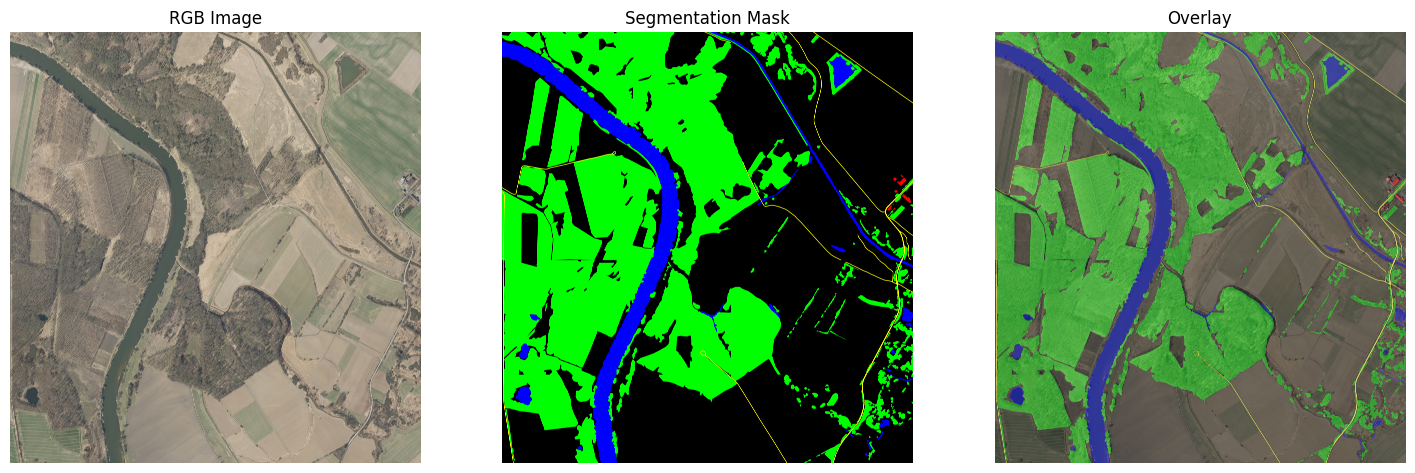

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title("RGB Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Segmentation Mask")
plt.imshow(color_mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [79]:
unique, counts = np.unique(filtered_masks, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 109176806
Class 1: 841464
Class 2: 50350660
Class 3: 7075952
Class 4: 6356590
